In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [2]:
x = np.array([1,2,3,4,5,6,7,8,9,10]).reshape(-1,1)

y = np.array([1,2,2.8,4.5,5.1,6.8,7.9,8.2,9.1,10.5])

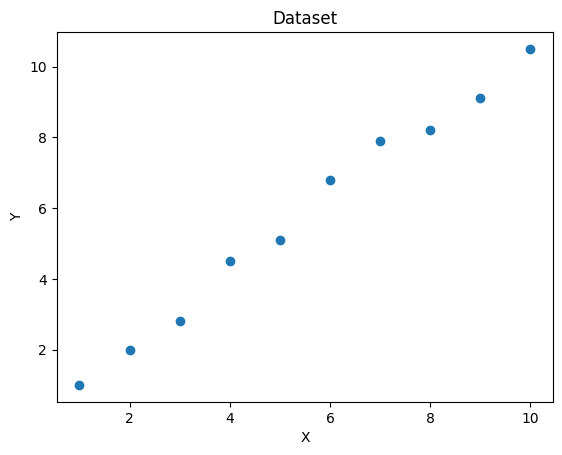

In [3]:
plt.scatter(x, y)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dataset")
plt.show()

In [4]:
model = LinearRegression()

model.fit(x, y)

y_pred = model.predict(x)

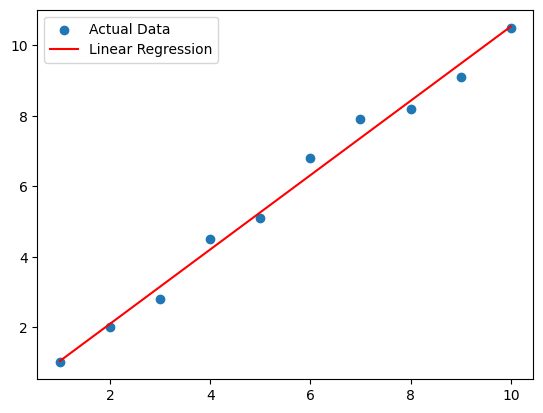

In [5]:
plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_pred, color="red", label="Linear Regression")
plt.legend()
plt.show()

In [6]:
overfit_model = make_pipeline(
    PolynomialFeatures(degree=10),
    LinearRegression()
)

overfit_model.fit(x, y)

y_overfit = overfit_model.predict(x)

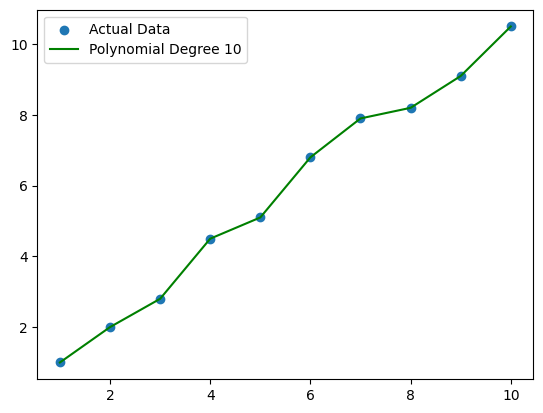

In [7]:
plt.scatter(x, y, label="Actual Data")
plt.plot(x, y_overfit, color="green", label="Polynomial Degree 10")
plt.legend()
plt.show()

In [8]:
print("Linear Regression R²:", model.score(x, y))

print("Polynomial Degree 10 R²:", overfit_model.score(x, y))

Linear Regression R²: 0.9896770722013963
Polynomial Degree 10 R²: 0.9999999999999976


In [9]:
x_new = np.array([[1.5], [2.5], [3.5], [4.5], [5.5], [6.5], [7.5], [8.5], [9.5]])

In [10]:
linear_pred = model.predict(x_new)

poly_pred = overfit_model.predict(x_new)

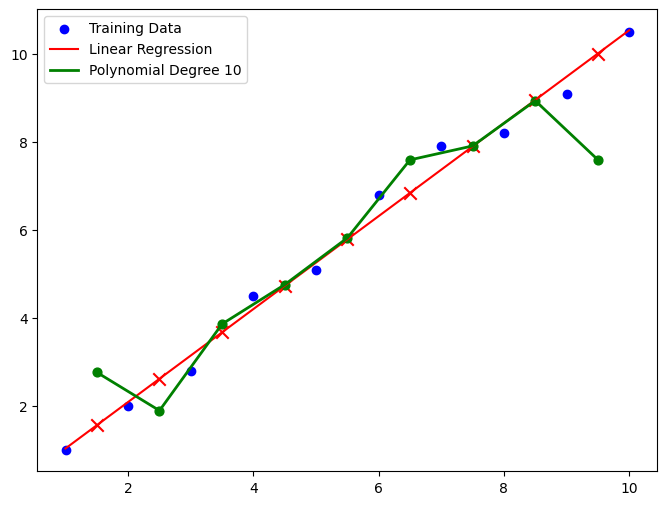

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, color="blue", label="Training Data")

plt.plot(x, y_pred, color="red", label="Linear Regression")

plt.plot(x_new, poly_pred, color="green", linewidth=2, label="Polynomial Degree 10")

plt.scatter(x_new, linear_pred, color="red", marker="x", s=80)

plt.scatter(x_new, poly_pred, color="green", marker="o", s=40)

plt.legend()
plt.show()

In [12]:
from sklearn.metrics import r2_score

In [13]:
x = np.linspace(-3, 3, 100).reshape(-1, 1)

y = x.ravel()**2 + np.random.normal(0, 1, 100)

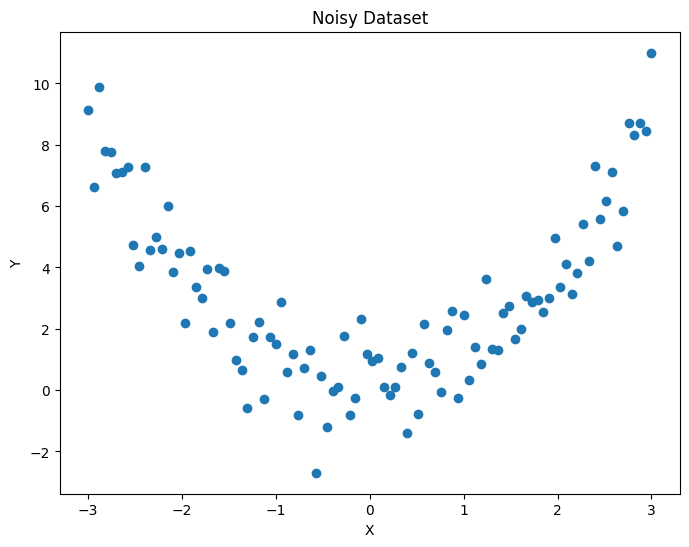

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(x, y)
plt.title("Noisy Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()


In [15]:
model1 = make_pipeline(
    PolynomialFeatures(degree=1),
    LinearRegression()
)

model1.fit(x, y)

y1 = model1.predict(x)

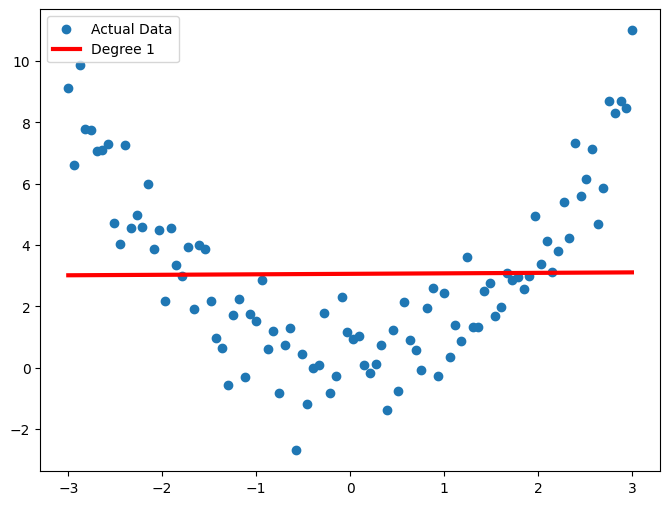

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label="Actual Data")

plt.plot(x, y1, color="red", linewidth=3, label="Degree 1")

plt.legend()

plt.show()

In [17]:
model2 = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

model2.fit(x, y)

y2 = model2.predict(x)

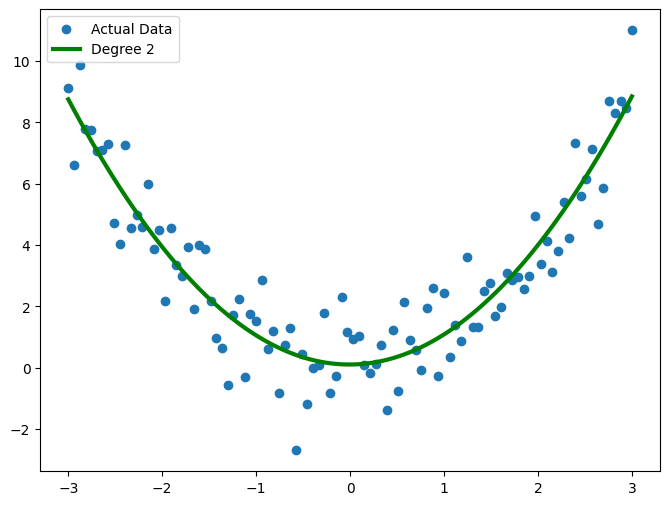

In [18]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label="Actual Data")

plt.plot(x, y2, color="green", linewidth=3, label="Degree 2")

plt.legend()

plt.show()

In [19]:
model15 = make_pipeline(
    PolynomialFeatures(degree=15),
    LinearRegression()
)

model15.fit(x, y)

y15 = model15.predict(x)

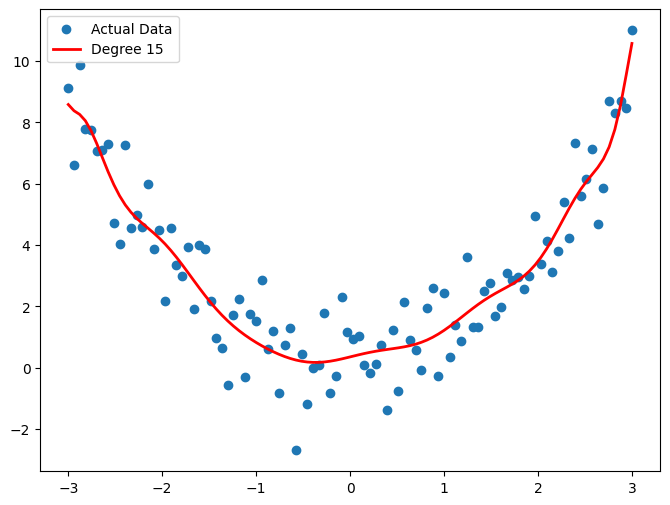

In [20]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label="Actual Data")

plt.plot(x, y15, color="red", linewidth=2, label="Degree 15")

plt.legend()

plt.show()

In [21]:
from sklearn.linear_model import Ridge

In [22]:
ridge = Ridge(alpha=1.0)

In [23]:
ridge.fit(x, y)
ridge_pred = ridge.predict(x)

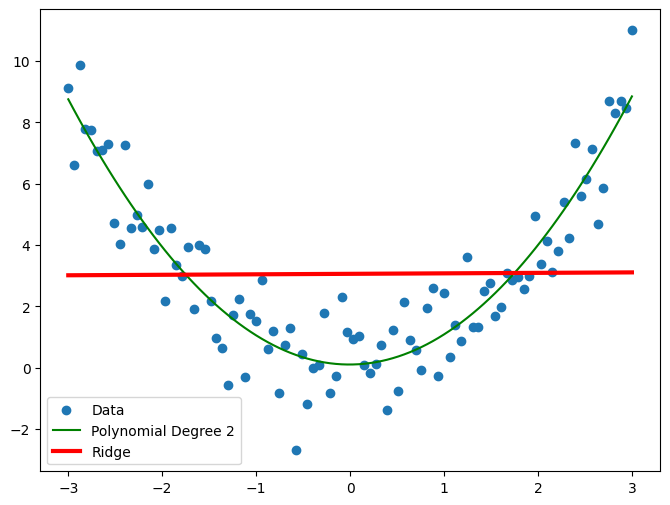

In [24]:
plt.figure(figsize=(8,6))

plt.scatter(x, y, label="Data")

plt.plot(x, y2, color="green", label="Polynomial Degree 2")

plt.plot(x, ridge_pred, color="red", linewidth=3, label="Ridge")

plt.legend()

plt.show()

In [25]:
ridge0 = Ridge(alpha=0)
ridge1 = Ridge(alpha=1)
ridge100 = Ridge(alpha=100)

ridge0.fit(x, y)
ridge1.fit(x, y)
ridge100.fit(x, y)

pred0 = ridge0.predict(x)
pred1 = ridge1.predict(x)
pred100 = ridge100.predict(x)

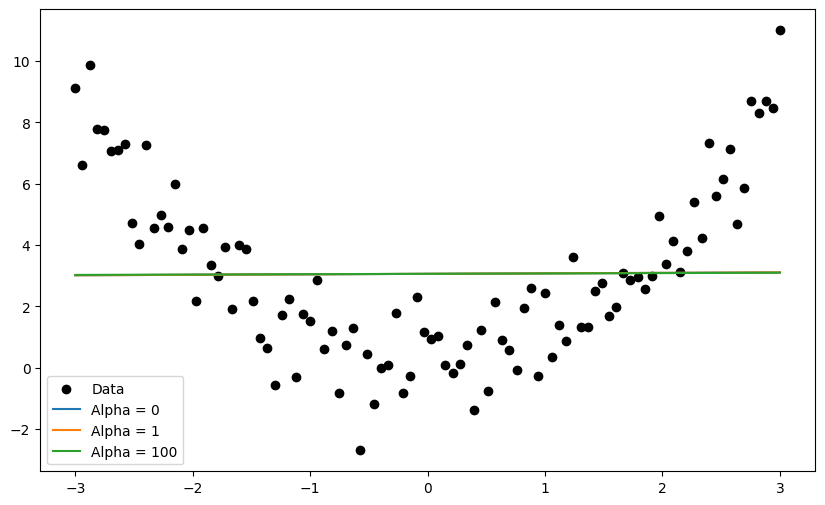

In [26]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, color="black", label="Data")

plt.plot(x, pred0, label="Alpha = 0")
plt.plot(x, pred1, label="Alpha = 1")
plt.plot(x, pred100, label="Alpha = 100")

plt.legend()
plt.show()

In [27]:
ridge0 = make_pipeline(
    PolynomialFeatures(degree=15),
    Ridge(alpha=0)
)

ridge1 = make_pipeline(
    PolynomialFeatures(degree=15),
    Ridge(alpha=1)
)

ridge100 = make_pipeline(
    PolynomialFeatures(degree=15),
    Ridge(alpha=100)
)

In [28]:
ridge0.fit(x, y)
ridge1.fit(x, y)
ridge100.fit(x, y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('polynomialfeatures', ...), ('ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",15
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",True
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",100
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True


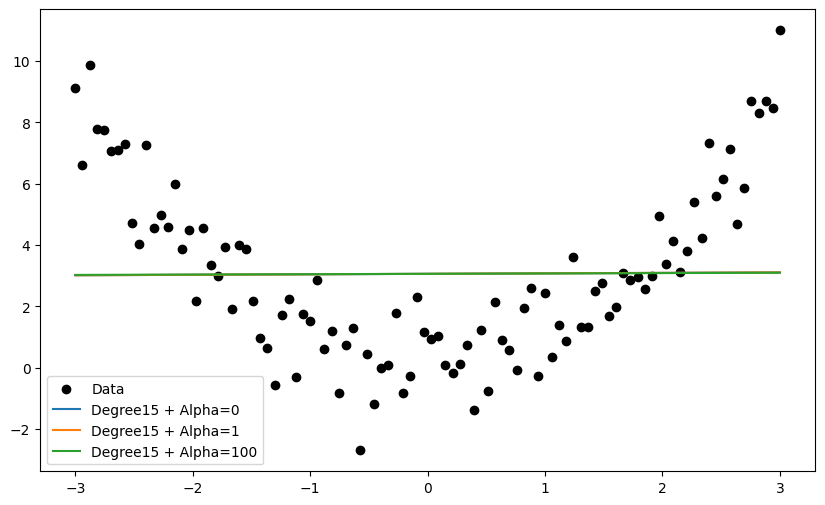

In [29]:
plt.figure(figsize=(10,6))

plt.scatter(x, y, color="black", label="Data")

plt.plot(x, pred0, label="Degree15 + Alpha=0")
plt.plot(x, pred1, label="Degree15 + Alpha=1")
plt.plot(x, pred100, label="Degree15 + Alpha=100")

plt.legend()
plt.show()

In [30]:
print(x.shape)
print(y.shape)
print(x[:5])
print(y[:5])

(100, 1)
(100,)
[[-3.        ]
 [-2.93939394]
 [-2.87878788]
 [-2.81818182]
 [-2.75757576]]
[9.12624895 6.61221283 9.88429331 7.78565877 7.74862538]


In [31]:
pred0 = ridge0.predict(x)
pred1 = ridge1.predict(x)
pred100 = ridge100.predict(x)

In [32]:
print(pred0[:10])
print(pred1[:10])
print(pred100[:10])

[8.5800595  8.37744224 8.2573963  8.05191877 7.72568116 7.30669758
 6.84435773 6.38623808 5.96729227 5.60675463]
[8.5619987  8.41873513 8.26668442 8.02667079 7.69066106 7.28475729
 6.84620924 6.41027852 6.00378922 5.64300522]
[8.29873282 8.70837057 8.53902409 8.09625657 7.56556172 7.05000573
 6.59812717 6.22421726 5.92271055 5.67808493]


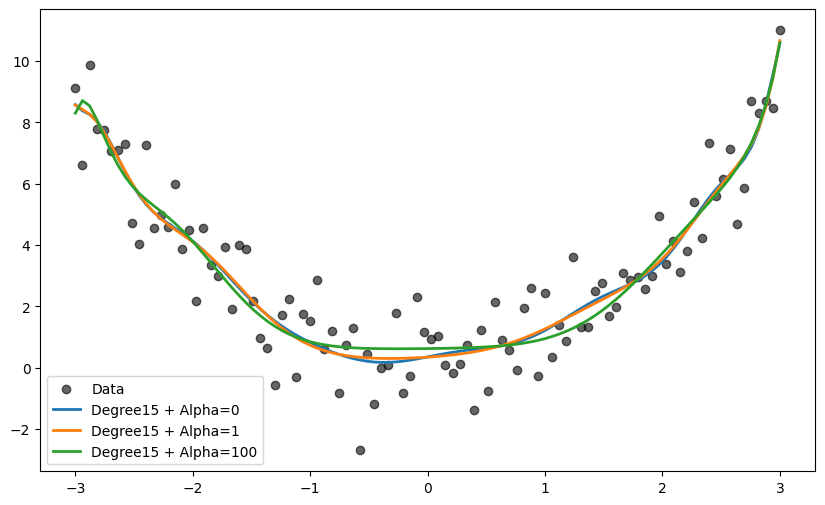

In [33]:
# Sort x for smooth plotting
idx = np.argsort(x.ravel())

x_sorted = x[idx]
pred0_sorted = pred0[idx]
pred1_sorted = pred1[idx]
pred100_sorted = pred100[idx]

plt.figure(figsize=(10,6))

plt.scatter(x, y, color="black", alpha=0.6, label="Data")

plt.plot(x_sorted, pred0_sorted, linewidth=2, label="Degree15 + Alpha=0")
plt.plot(x_sorted, pred1_sorted, linewidth=2, label="Degree15 + Alpha=1")
plt.plot(x_sorted, pred100_sorted, linewidth=2, label="Degree15 + Alpha=100")

plt.legend()
plt.show()